# Utqiagvik **T2m vs. other variables** Analysis 
- MESACLIP all box sizes
- Bowhead whale hunting relationships between annual mean temperature and other environmental variables
- Notebook by Alice DuVivier (NCAR)
- January 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cmocean
import geopandas as gpd
from metpy.calc import wind_speed
from metpy.calc import wind_direction
from scipy.stats import linregress,pearsonr, t, ttest_ind

## Load Observational Data

### Load Barrow Observatory Data
- Temperature and 10m wind speed

In [2]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/NOAA_GML_BRW_MET/'

In [3]:
# years from 1974-2024
years_obs_brw = np.arange(1974,2025,1)
nyrs = len(years_obs_brw)
print(nyrs)

51


#### Temperature

In [4]:
# preallocate some arrays
avg_array = np.zeros([nyrs])

# loop through each year to get the data and calculate annual average
for index, yy in enumerate(years_obs_brw):
    file_in = 'brw_met_'+str(yy)+'.csv'
    #print(file_in)
    # load data with pandas
    df = pd.read_csv(dir_in+file_in)
    # read just the temperature values
    temp1 = df['T2m']
    # replace missing values (-999.9) with NaN
    temp2 = temp1.where(temp1> -999.9)
    # calculate annual mean and put this into an array
    avg_array[index] = temp2.mean()

# convert the numpy arrays to xarrays for easier plotting
data_obs_temp = xr.DataArray(avg_array,dims=('years'))
data_obs_temp['years'] = years_obs_brw

In [5]:
# calculate an average temperature for 2000-2020
data_obs_sub = data_obs_temp.where(data_obs_temp.years >= 2000,drop=True)
data_obs_sub = data_obs_sub.where(data_obs_sub.years <= 2020, drop=True)
temp_avg_2000_2020 = data_obs_sub.mean()
temp_std_2000_2020 = data_obs_sub.std()
print(temp_avg_2000_2020)
print(temp_std_2000_2020)

# calculate an average temperature for 2014-2024
data_obs_sub = data_obs_temp.where(data_obs_temp.years >= 2014,drop=True)
temp_avg_2014_2024 = data_obs_sub.mean()
temp_std_2014_2024 = data_obs_sub.std()
print(temp_avg_2014_2024)
print(temp_std_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(1.2872061)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)
<xarray.DataArray ()> Size: 8B
array(1.55803959)


#### 10m wind speed

In [6]:
# preallocate some arrays
avg_array = np.zeros([nyrs,365])

# loop through each year to get the data and calculate annual average
for index, yy in enumerate(years_obs_brw):
    #print(yy)
    file_in = 'brw_met_'+str(yy)+'.csv'
    #print(file_in)
    # load data with pandas
    df = pd.read_csv(dir_in+file_in)
    # rename columns to work with datetime
    df = df.rename(columns={'YYYY':'year','MM':'month', 'DD':'day','HH':'hour'})
    # create datetime from time data
    df['date_col'] = pd.to_datetime(df[['year','month','day','hour']])
    # set new date column as index
    df = df.set_index('date_col')     
    # read just the wind speed values
    temp1 = df['WndSpd']
    # replace missing values (-99.9) with NaN and put this into an array
    temp2 = temp1.where(temp1> -99.9)
    # create daily averages
    temp3 = temp2.resample('D').mean() 
    # if a leap year, remove leap day hours
    if (yy==1976)or(yy==1980)or(yy==1984)or(yy==1988)or(yy==1992)or(yy==1996)or(yy==2000)or(yy==2004)or(yy==2008)or(yy==2012)or(yy==2016)or(yy==2020)or(yy==2024):
        print(str(yy)+': Leap year - removing leapday')
        dstr = str(yy)+'-02-29'
        temp3 = temp3.drop(pd.Timestamp(dstr))
    # look at dates for the series
    #dates = temp3.index.to_series()
    # fill array with this data
    avg_array[index,:] = temp3

# convert the numpy arrays to xarrays for easier plotting
data_obs = xr.DataArray(avg_array,dims=('years','doy'))
data_obs['years'] = years_obs_brw

1976: Leap year - removing leapday
1980: Leap year - removing leapday
1984: Leap year - removing leapday
1988: Leap year - removing leapday
1992: Leap year - removing leapday
1996: Leap year - removing leapday
2000: Leap year - removing leapday
2004: Leap year - removing leapday
2008: Leap year - removing leapday
2012: Leap year - removing leapday
2016: Leap year - removing leapday
2020: Leap year - removing leapday
2024: Leap year - removing leapday


<xarray.DataArray ()> Size: 8B
array(95.20416667)


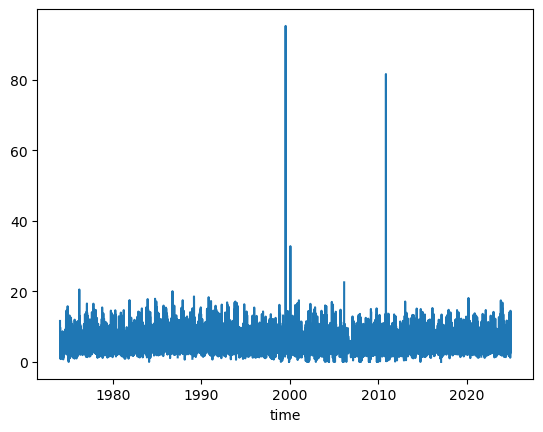

In [7]:
# actually want all data in one array
data_obs_all = data_obs.stack(time=("years", "doy"))

# make array of the dates
daily_dates = pd.date_range(start="1974-01-01", end="2024-12-31", freq="D")
# remove leap days
filtered_dates = daily_dates[~((daily_dates.month == 2) & (daily_dates.day == 29))]

# reassign the time array
data_obs_all['time'] = filtered_dates

# look at data quickly
print(data_obs_all.max())
data_obs_all.plot()

In [8]:
# Average for Fall
data_obs_seas = data_obs_all.isel(time=data_obs_all.time.dt.month.isin([9,10,11]))

# preallocate some arrays
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_obs_brw):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_obs_seas.isel(time=data_obs_seas.time.dt.year.isin([yy]))
    # calculate mean
    avg_array[index] = temp1.mean(dim='time')
    # calculate standard deviation
    std_array[index] = temp1.std(dim='time')

# convert the numpy arrays to xarrays for easier plotting
data_obs_ws = xr.DataArray(avg_array,dims=('years'))
data_obs_ws['years'] = years_obs_brw

### Satellite SIC data

In [9]:
years_obs_sic = np.arange(1979,2022,1)

In [10]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/ssmi_cdr/'
file_in = 'Utqiagvik_SSMI_CDR_1979-2021_daily-SIC.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [11]:
# look at dataset
#ds

# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1979', end='12/31/2021', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# data
data_obs_sic = ds.sic

(15695,)


In [12]:
# years from 1979-2021
years_obs_sic = np.arange(1979,2022,1)
nyrs = len(years_obs_sic)
print(nyrs)

43


In [13]:
### Process to get spring mean values
# subset data to just spring - April and May
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_obs_sic):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_obs_sic.isel(time=data_obs_sic.time.dt.year.isin([yy]))
    # get spring months only
    temp2 = temp1.isel(time=temp1.time.dt.month.isin([3,4]))
    # calculate mean
    avg_array[index] = temp2.mean(dim='time')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='time')

# convert the numpy arrays to xarrays for easier plotting
obs_sic_avg = xr.DataArray(avg_array,dims=('years'))
obs_sic_avg['years'] = years_obs_sic
obs_sic_std = xr.DataArray(std_array,dims=('years'))
obs_sic_std['years'] = years_obs_sic

### PIOMAS SIT data

In [14]:
years_obs_sit = np.arange(1979,2020,1)

In [15]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/piomas/'
file_in = 'Utqiagvik_PIOMAS_1979-2019_daily-SIC.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [16]:
# look at dataset
#ds

# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1979', end='12/31/2019', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# get data
data_obs_sit = ds.sit

(14965,)


In [17]:
# years from 1979-2020
years_obs_sit = np.arange(1979,2020,1)
nyrs = len(years_obs_sit)
print(nyrs)

41


In [18]:
### Process to get spring mean values

# subset data to just spring - April and May
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_obs_sit):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_obs_sit.isel(time=data_obs_sit.time.dt.year.isin([yy]))
    # get spring months only
    temp2 = temp1.isel(time=temp1.time.dt.month.isin([3,4]))
    # calculate mean
    avg_array[index] = temp2.mean(dim='time')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='time')

# convert the numpy arrays to xarrays for easier plotting
obs_sit_avg = xr.DataArray(avg_array,dims=('years'))
obs_sit_avg['years'] = years_obs_sit
obs_sit_std = xr.DataArray(std_array,dims=('years'))
obs_sit_std['years'] = years_obs_sit

## Load MESACLIP Model Data

In [19]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

### Temperature

In [20]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/1920', end='12/31/2005', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# convert to C from K
ds = ds - 273.15

# keep this data
data_mesa_hist_temp = ds

In [21]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/2006', end='12/31/2104', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# convert to C from K
ds = ds - 273.15

# keep this data
data_mesa_rcp60_temp = ds

In [22]:
# concatenate historical and rcp60
data_mesa_temp = xr.concat([data_mesa_hist_temp,data_mesa_rcp60_temp], dim='time')

In [23]:
# get three sizes to compare
temp_mesaclip_pt = data_mesa_temp.data_pt
temp_mesaclip_small_box = data_mesa_temp.data_small_box
temp_mesaclip = data_mesa_temp.data_big_box

### 10m wind speed

In [24]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-U10.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='1/1/2006', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_ws = ds

In [25]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-U10.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='1/1/2101', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_rcp60_ws = ds

(34676,)


In [26]:
# concatenate historical and rcp60
data_mesa_ws = xr.concat([data_mesa_hist_ws,data_mesa_rcp60_ws], dim='time')

In [27]:
# get three sizes to compare
ws_mesaclip_pt = data_mesa_ws.data_pt
ws_mesaclip_small_box = data_mesa_ws.data_small_box
ws_mesaclip = data_mesa_ws.data_big_box

### Lowest Level wind speed

In [28]:
# historical data
file_in1 = 'Utqiagvik_MESACLIP_HIST_daily-UBOT.nc'
ds1 = xr.open_mfdataset(dir_in+file_in1, decode_times=False)
file_in2 = 'Utqiagvik_MESACLIP_HIST_daily-VBOT.nc'
ds2 = xr.open_mfdataset(dir_in+file_in2, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
ndates = dates.shape
ndates = ndates[0]
#print(ndates)

# get number of ensemble members for this data
nens = len(ds1.member_id)

# assign the time coordinate
ds1['time'] = dates
ds2['time'] = dates

ds1_hist = ds1
ds2_hist = ds2

In [29]:
# rcp6.0 data
file_in1 = 'Utqiagvik_MESACLIP_RCP6.0_daily-UBOT.nc'
ds1 = xr.open_mfdataset(dir_in+file_in1, decode_times=False)
file_in2 = 'Utqiagvik_MESACLIP_RCP6.0_daily-VBOT.nc'
ds2 = xr.open_mfdataset(dir_in+file_in2, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
ndates = dates.shape
ndates = ndates[0]
#print(ndates)

# get number of ensemble members for this data
nens = len(ds1.member_id)

# assign the time coordinate
ds1['time'] = dates
ds2['time'] = dates

ds1_ssp = ds1
ds2_ssp = ds2

In [30]:
# concatenate data
ds1_ssp = ds1_ssp.isel(member_id=slice(1,10))
ds1 = xr.concat([ds1_hist,ds1_ssp],dim='time')

ds2_ssp = ds2_ssp.isel(member_id=slice(1,10))
ds2 = xr.concat([ds2_hist,ds2_ssp],dim='time')

In [31]:
# get number of dates
ndates = ds1.time.shape
ndates = int(ndates[0])
print(ndates)

# get number of ensembles
nens_mesaclip = ds1.member_id.shape
nens_mesaclip = int(nens_mesaclip[0])
print(nens_mesaclip)

66065
9


In [32]:
### calculate wind speeds

# single pt
data1 = ds1.data_pt
data2 = ds2.data_pt
ws_temp = wind_speed(data1,data2)
# put into an xarray more nicely because currently it causes issues with calculations
array = np.zeros([nens_mesaclip,ndates])
array[:,:] = ws_temp.values
# convert the numpy arrays to xarrays for easier plotting
#ws_mesaclip_pt = xr.DataArray(array,dims=('member_id','time'))
#ws_mesaclip_pt['member_id'] = ds1.member_id
#ws_mesaclip_pt['time'] = ds1.time

# small box
data1 = ds1.data_small_box.assign_attrs(units=ds1.data_pt.units, long_name=ds1.data_pt.long_name)
data2 = ds2.data_small_box.assign_attrs(units=ds2.data_pt.units, long_name=ds2.data_pt.long_name)
ws_temp = wind_speed(data1,data2)
# put into an xarray more nicely because currently it causes issues with calculations
array = np.zeros([nens_mesaclip,ndates])
array[:,:] = ws_temp.values
# convert the numpy arrays to xarrays for easier plotting
#ws_mesaclip_small_box = xr.DataArray(array,dims=('member_id','time'))
#ws_mesaclip_small_box['member_id'] = ds1.member_id
#ws_mesaclip_small_box['time'] = ds1.time

# big box
data1 = ds1.data_big_box.assign_attrs(units=ds1.data_pt.units, long_name=ds1.data_pt.long_name)
data2 = ds2.data_big_box.assign_attrs(units=ds2.data_pt.units, long_name=ds2.data_pt.long_name)
ws_temp = wind_speed(data1,data2)
# put into an xarray more nicely because currently it causes issues with calculations
array = np.zeros([nens_mesaclip,ndates])
array[:,:] = ws_temp.values
# convert the numpy arrays to xarrays for easier plotting
#ws_mesaclip = xr.DataArray(array,dims=('member_id','time'))
#ws_mesaclip['member_id'] = ds1.member_id
#ws_mesaclip['time'] = ds1.time

### SIC

In [33]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_sic = ds

In [34]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_rcp60_sic = ds

In [35]:
# concatenate historical and rcp60 but have to drop one ensemble member from future 
data_mesa_rcp60_sic = data_mesa_rcp60_sic.isel(member_id=slice(1,10))
data_mesa_sic = xr.concat([data_mesa_hist_sic,data_mesa_rcp60_sic], dim='time')

In [36]:
# keep this data
sic_mesaclip_pt = data_mesa_sic.data_pt
sic_mesaclip_small_box = data_mesa_sic.data_small_box
sic_mesaclip = data_mesa_sic.data_big_box

### SIT

In [37]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_hist_sit = ds

In [38]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# keep this data
data_mesa_rcp60_sit = ds

In [39]:
# concatenate historical and rcp60 but have to drop one ensemble member from future 
data_mesa_rcp60_sit = data_mesa_rcp60_sit.isel(member_id=slice(1,10))
data_mesa_sit = xr.concat([data_mesa_hist_sit,data_mesa_rcp60_sit], dim='time')

In [40]:
# keep this data
sit_mesaclip_pt = data_mesa_sit.data_pt
sit_mesaclip_small_box = data_mesa_sit.data_small_box
sit_mesaclip = data_mesa_sit.data_big_box

## Process T2m Model Data
- Timeseries: We need to first calculate the annual mean from daily data. Then from the annual mean temperatures for each ensemble member, we calculate mean and standard deviation. If we use daily data and average across everything then the variance is huge because of the annual cycle.

In [41]:
# years from 1920-2100
years_model = np.arange(1920,2101,1)
nyrs = len(years_model)
print(nyrs)

181


In [42]:
# MESACLIP
# 3 box size options!

### single pt
data_model = temp_mesaclip_pt
# get number of ensembles - used for all three sizes
nens_mesaclip = data_model.member_id.shape
nens_mesaclip = int(nens_mesaclip[0])
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_pt_avg = model_ens_avg
mesaclip_pt_std = model_ens_std

### small box
data_model = temp_mesaclip_small_box
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_small_box_avg = model_ens_avg
mesaclip_small_box_std = model_ens_std

### big box
data_model = temp_mesaclip
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
### Write variables
mesaclip_avg = model_ens_avg
mesaclip_std = model_ens_std

## Process Spring SIC Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times below SIC thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [43]:
# days are all days in April and May
ndays_spr = 30 + 31

In [44]:
# subset to just this season
sic_mesaclip_seas = sic_mesaclip.isel(time=sic_mesaclip.time.dt.month.isin([3,4]))
sic_mesaclip_pt_seas = sic_mesaclip_pt.isel(time=sic_mesaclip_pt.time.dt.month.isin([3,4]))
sic_mesaclip_small_box_seas = sic_mesaclip_small_box.isel(time=sic_mesaclip_small_box.time.dt.month.isin([3,4]))

### Calculate Seasonal Annual Average

In [45]:
# MESACLIP - calculate mean across all days and ensembles
# 3 box size options!

### single pt
data_model = sic_mesaclip_pt_seas
# get number of ensembles - used for all three sizes
nens_mesaclip = data_model.member_id.shape
nens_mesaclip = int(nens_mesaclip[0])
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_sic_pt_avg = model_ens_avg
mesaclip_sic_pt_std = model_ens_std

### small box
data_model = sic_mesaclip_small_box_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_sic_small_box_avg = model_ens_avg
mesaclip_sic_small_box_std = model_ens_std

### big box
data_model = sic_mesaclip_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
### Write variables
mesaclip_sic_avg = model_ens_avg
mesaclip_sic_std = model_ens_std

### Calculate threshold frequencies

SIC thresholds
- Covered:  SIC>=85%
- MIZ:      15%<SIC<85%
- Ice free: SIC<15%

In [46]:
# set thresholds
thresh1 = 85.0
thresh2 = 15.0

In [47]:
# MESACLIP - calculate frequency for thresholds
# All 3 box sizes

data_model = sic_mesaclip_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip['years'] = years_model
sic_thresh2_mesaclip = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip['years'] = years_model

### single pt
data_model = sic_mesaclip_pt_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip_pt = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip_pt['years'] = years_model
sic_thresh2_mesaclip_pt = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip_pt['years'] = years_model

### small box
data_model = sic_mesaclip_small_box_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip_small_box = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip_small_box['years'] = years_model
sic_thresh2_mesaclip_small_box = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip_small_box['years'] = years_model

## Process Spring SIT Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times below SIT thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [48]:
# days are all days in April and May
ndays_spr = 30 + 31

In [49]:
# subset to just this season
sit_mesaclip_seas = sit_mesaclip.isel(time=sit_mesaclip.time.dt.month.isin([3,4]))
sit_mesaclip_pt_seas = sit_mesaclip_pt.isel(time=sit_mesaclip_pt.time.dt.month.isin([3,4]))
sit_mesaclip_small_box_seas = sit_mesaclip_small_box.isel(time=sit_mesaclip_small_box.time.dt.month.isin([3,4]))

### Calculate Seasonal Annual Average

In [50]:
# MESACLIP - calculate mean across all days and ensembles
# 3 box size options!

### single pt
data_model = sit_mesaclip_pt_seas
# get number of ensembles - used for all three sizes
nens_mesaclip = data_model.member_id.shape
nens_mesaclip = int(nens_mesaclip[0])
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_sit_pt_avg = model_ens_avg
mesaclip_sit_pt_std = model_ens_std

### small box
data_model = sit_mesaclip_small_box_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_sit_small_box_avg = model_ens_avg
mesaclip_sit_small_box_std = model_ens_std

### big box
data_model = sit_mesaclip_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
### Write variables
mesaclip_sit_avg = model_ens_avg
mesaclip_sit_std = model_ens_std

### Calculate threshold frequencies

SIT thresholds
- SIT<1m
- SIT<2m
- Curry and Lopez 2020 say that a minimum of 3-4ft (1m-1.2m) ice thickness is needed for a whale

In [51]:
# set thresholds
thresh1 = 2.0
thresh2 = 1.0

In [52]:
# MESACLIP
# 3 box sizes

data_model = sit_mesaclip_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip['years'] = years_model
sit_thresh2_mesaclip = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip['years'] = years_model

### single pt
data_model = sit_mesaclip_pt_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip_pt = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip_pt['years'] = years_model
sit_thresh2_mesaclip_pt = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip_pt['years'] = years_model

### small box
data_model = sit_mesaclip_small_box_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip_small_box = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip_small_box['years'] = years_model
sit_thresh2_mesaclip_small_box = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip_small_box['years'] = years_model

## Process Autumn WS Model Data
- Two calculations:
   - Calculate the spring mean across all days and ensembles for timeseries plot
   - Calculate the annual frequency of times below SIT thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs. This will be in the scatter plot against temperature

In [53]:
# days are all days in SON
ndays_fall = 30 + 31 + 30

In [54]:
# subset to just this season
ws_mesaclip_seas = ws_mesaclip.isel(time=ws_mesaclip.time.dt.month.isin([9,10,11]))
ws_mesaclip_pt_seas = ws_mesaclip_pt.isel(time=ws_mesaclip_pt.time.dt.month.isin([9,10,11]))
ws_mesaclip_small_box_seas = ws_mesaclip_small_box.isel(time=ws_mesaclip_small_box.time.dt.month.isin([9,10,11]))

### Calculate Seasonal Annual Average

In [55]:
# MESACLIP - calculate mean across all days and ensembles
# 3 box size options!

### single pt
data_model = ws_mesaclip_pt_seas
# get number of ensembles - used for all three sizes
nens_mesaclip = data_model.member_id.shape
nens_mesaclip = int(nens_mesaclip[0])
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_ws_pt_avg = model_ens_avg
mesaclip_ws_pt_std = model_ens_std

### small box
data_model = ws_mesaclip_small_box_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_ws_small_box_avg = model_ens_avg
mesaclip_ws_small_box_std = model_ens_std

### big box
data_model = ws_mesaclip_seas
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
### Write variables
mesaclip_ws_avg = model_ens_avg
mesaclip_ws_std = model_ens_std

### Calculate threshold frequencies

WS thresholds
- WS>11m/s - from Ana Stringer's thesis for large boats
- WS>17m/s - "Gale" on the Beaufort Scale

In [56]:
# set thresholds
thresh1 = 11.0
thresh2 = 17.0

In [57]:
# MESACLIP
# 3 box sizes

data_model = ws_mesaclip_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with WS>11m/s conditions
    count = len(temp2.where((temp2 > thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with WS>17m/s conditions
    count = len(temp2.where((temp2 > thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
ws_thresh1_mesaclip = xr.DataArray(array_1,dims=('years'))
ws_thresh1_mesaclip['years'] = years_model
ws_thresh2_mesaclip = xr.DataArray(array_2,dims=('years'))
ws_thresh2_mesaclip['years'] = years_model

### single pt
data_model = ws_mesaclip_pt_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with WS>11m/s conditions
    count = len(temp2.where((temp2 > thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with WS>17m/s conditions
    count = len(temp2.where((temp2 > thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
ws_thresh1_mesaclip_pt = xr.DataArray(array_1,dims=('years'))
ws_thresh1_mesaclip_pt['years'] = years_model
ws_thresh2_mesaclip_pt = xr.DataArray(array_2,dims=('years'))
ws_thresh2_mesaclip_pt['years'] = years_model

### small box
data_model = ws_mesaclip_small_box_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with WS>11m/s conditions
    count = len(temp2.where((temp2 > thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with WS>17m/s conditions
    count = len(temp2.where((temp2 > thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
ws_thresh1_mesaclip_small_box = xr.DataArray(array_1,dims=('years'))
ws_thresh1_mesaclip_small_box['years'] = years_model
ws_thresh2_mesaclip_small_box = xr.DataArray(array_2,dims=('years'))
ws_thresh2_mesaclip_small_box['years'] = years_model

## Calculate linear regressions

In [74]:
# set temperature range for regression
tmin = -13
tmax = 1

# set range for where we'll plot regression
x_reg = np.arange(tmin,tmax+1,1)

### SIC

In [91]:
## MESACLIP - big box
print('MESACLIP - big box')
# select data
xdata = mesaclip_avg
ydata = sic_thresh1_mesaclip
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_mesaclip_bb = y_reg
rate_sic_mesaclip_bb = str(round(rate,1))
r2_sic_mesaclip_bb = str(round(r2,2))

MESACLIP - big box
SIC rate 2.167 %/C; $r^{2}$=0.75


In [92]:
## MESACLIP - small box
print('MESACLIP - small box')
# select data
xdata = mesaclip_avg
ydata = sic_thresh1_mesaclip_small_box
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_mesaclip_sb = y_reg
rate_sic_mesaclip_sb = str(round(rate,1))
r2_sic_mesaclip_sb = str(round(r2,2))

MESACLIP - small box
SIC rate 2.003 %/C; $r^{2}$=0.68


In [93]:
## MESACLIP - pt
print('MESACLIP - pt')
# select data
xdata = mesaclip_avg
ydata = sic_thresh1_mesaclip_pt
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_mesaclip_pt = y_reg
rate_sic_mesaclip_pt = str(round(rate,1))
r2_sic_mesaclip_pt = str(round(r2,2))

MESACLIP - pt
SIC rate 1.815 %/C; $r^{2}$=0.63


### SIT

In [94]:
## MESACLIP - big box
print('MESACLIP - big box')
# select data
xdata = mesaclip_avg
ydata = sit_thresh1_mesaclip
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_mesaclip_bb = y_reg
rate_sit_mesaclip_bb = str(round(rate,1))
r2_sit_mesaclip_bb = str(round(r2,2))

MESACLIP - big box
SIC rate 8.952 %/C; $r^{2}$=0.91


In [95]:
## MESACLIP - small box
print('MESACLIP - small box')
# select data
xdata = mesaclip_avg
ydata = sit_thresh1_mesaclip_small_box
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_mesaclip_sb = y_reg
rate_sit_mesaclip_sb = str(round(rate,1))
r2_sit_mesaclip_sb = str(round(r2,2))

MESACLIP - small box
SIC rate 7.198 %/C; $r^{2}$=0.92


In [96]:
## MESACLIP - pt
print('MESACLIP - pt')
# select data
xdata = mesaclip_avg
ydata = sit_thresh1_mesaclip_pt
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_mesaclip_pt = y_reg
rate_sit_mesaclip_pt = str(round(rate,1))
r2_sit_mesaclip_pt = str(round(r2,2))

MESACLIP - pt
SIC rate 4.958 %/C; $r^{2}$=0.85


### WS

In [97]:
## MESACLIP - big box
print('MESACLIP - big box')
# select data
xdata = mesaclip_avg
ydata = ws_thresh1_mesaclip
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_ws_reg_mesaclip_bb = y_reg
rate_ws_mesaclip_bb = str(round(rate,1))
r2_ws_mesaclip_bb = str(round(r2,2))

MESACLIP - big box
SIC rate 0.74 %/C; $r^{2}$=0.35


In [98]:
## MESACLIP - small box
print('MESACLIP - small box')
# select data
xdata = mesaclip_avg
ydata = ws_thresh1_mesaclip_small_box
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_ws_reg_mesaclip_sb = y_reg
rate_ws_mesaclip_sb = str(round(rate,1))
r2_ws_mesaclip_sb = str(round(r2,2))

MESACLIP - small box
SIC rate 0.35 %/C; $r^{2}$=0.13


In [99]:
## MESACLIP - pt
print('MESACLIP - pt')
# select data
xdata = mesaclip_avg
ydata = ws_thresh1_mesaclip_pt
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_ws_reg_mesaclip_pt = y_reg
rate_ws_mesaclip_pt = str(round(rate,1))
r2_ws_mesaclip_pt = str(round(r2,2))

MESACLIP - pt
SIC rate 0.319 %/C; $r^{2}$=0.11


## Plot timeseries and scatter plots

In [100]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_5/'

In [101]:
# calculate an average temperature for 2000-2020
print(temp_avg_2000_2020)

# calculate an average temperature for 2014-2024
print(temp_avg_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)


In [102]:
# xticks for timeseries
xticks_ts = np.arange(1920,2100,40)
# xticks for scatter
xticks_sc = np.arange(-13,2,2)
# yticks for scatter
yticks_sc = np.arange(0,100,10)

### All Models on one Plot

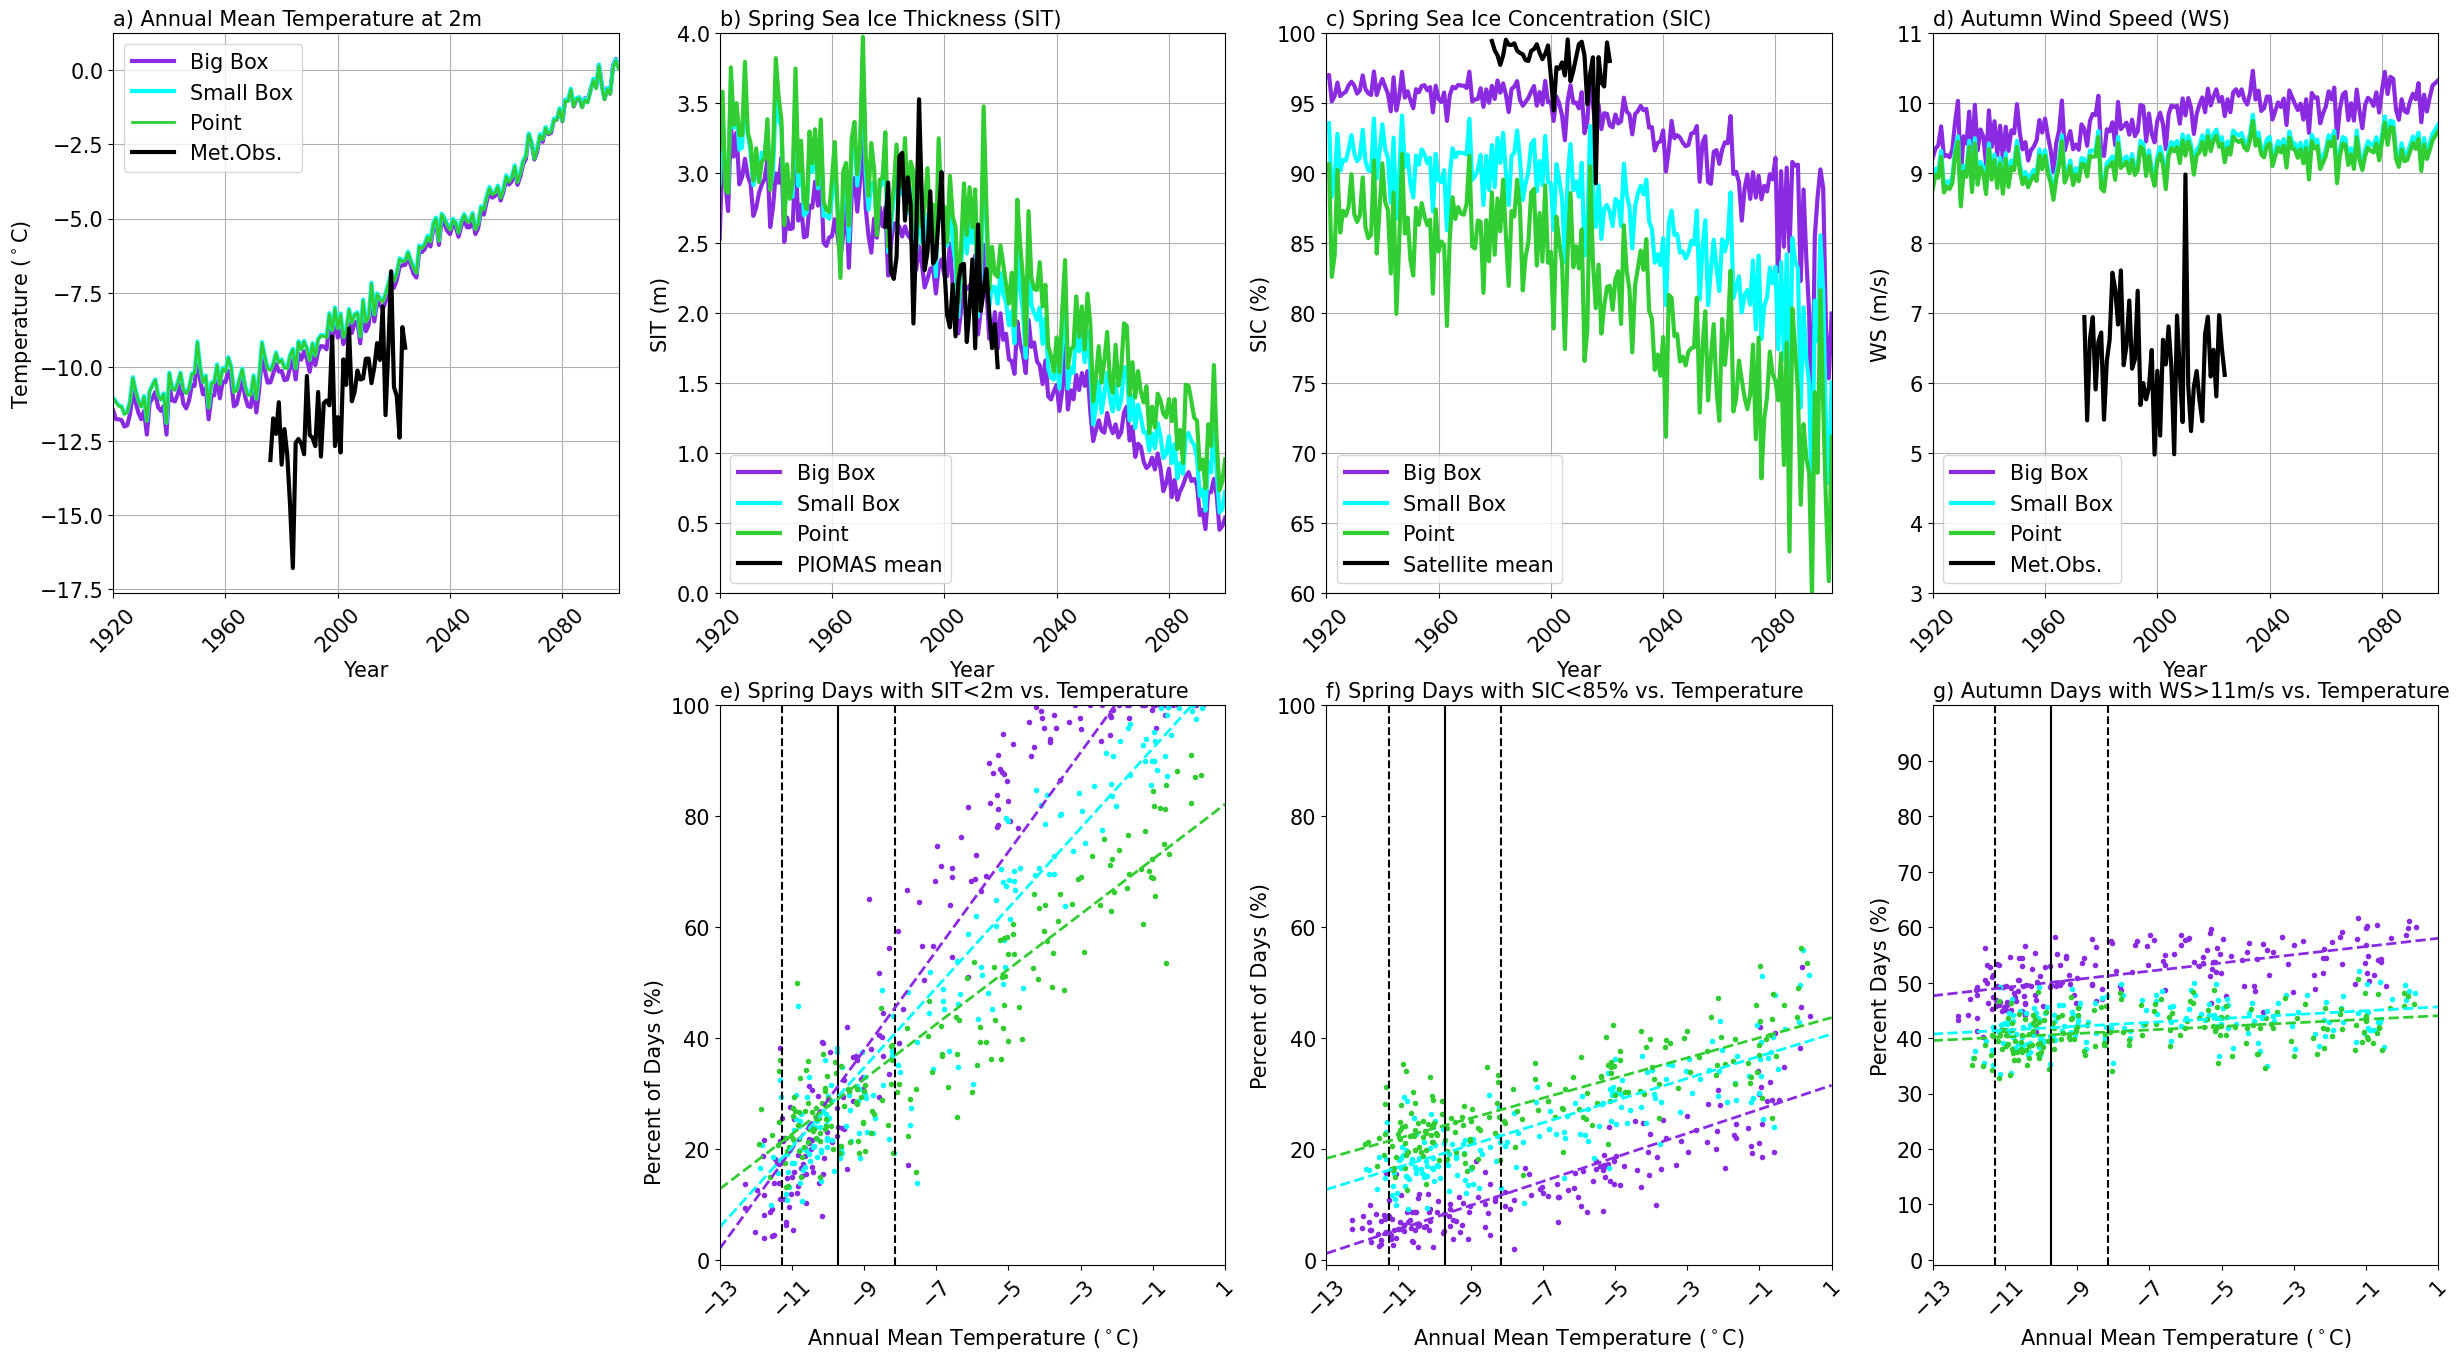

In [126]:
# create figure
#fig = plt.figure(figsize=(20,12))
fig = plt.figure(figsize=(30,16))
# now loop through months to create subpanels
fout = 'fig_7_utq_timeseries_temperature_scatter'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### First grouping: Mean State Comparison
### Plot 1 - T2m ###
ax = fig.add_subplot(2,4,1)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_avg
data_std = mesaclip_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_small_box_avg
data_std = mesaclip_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_pt_avg
data_std = mesaclip_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=2)
# Obs from Barrow Observatory
ax.plot(years_obs_brw,data_obs_temp,color="black",label='Met.Obs.',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('a) Annual Mean Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
ax.set_xticks(xticks_ts)
plt.xlim([1920,2100])
plt.ylabel('Temperature ($^\\circ$C)',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([-1,100.0])
plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - SIT ###
ax = fig.add_subplot(2,4,2)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_sit_avg
data_std = mesaclip_sit_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_sit_small_box_avg
data_std = mesaclip_sit_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_sit_pt_avg
data_std = mesaclip_sit_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from PIOMAS
ax.plot(years_obs_sit,obs_sit_avg,color="black",label='PIOMAS mean',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('b) Spring Sea Ice Thickness (SIT)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIT (m)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,4])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 3 - SIC ###
ax = fig.add_subplot(2,4,3)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_sic_avg
data_std = mesaclip_sic_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_sic_small_box_avg
data_std = mesaclip_sic_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_sic_pt_avg
data_std = mesaclip_sic_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from SSMI
ax.plot(years_obs_sic,obs_sic_avg,color="black",label='Satellite mean',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('c) Spring Sea Ice Concentration (SIC)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIC (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([60,100])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 4 - WS ###
ax = fig.add_subplot(2,4,4)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_ws_avg
data_std = mesaclip_ws_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_ws_small_box_avg
data_std = mesaclip_ws_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_ws_pt_avg
data_std = mesaclip_ws_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from Barrow Observatory
ax.plot(years_obs_brw,data_obs_ws,color="black",label='Met.Obs.',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('d) Autumn Wind Speed (WS)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('WS (m/s)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([3,11])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

############
### Second grouping - Temp vs. variable
### Plot 6 - T2m vs. SIT ###
ax = fig.add_subplot(2,4,6)
# set data
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="blueviolet",marker=".",label='MESACLIP - Big Box')
ax.scatter(mesaclip_small_box_avg,sit_thresh1_mesaclip_small_box,color="cyan",marker=".",label='MESACLIP - Small Box')
ax.scatter(mesaclip_pt_avg,sit_thresh1_mesaclip_pt,color="limegreen",marker=".",label='MESACLIP - Pt')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_sit_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_sit_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_bb)
ax.plot(x_reg,y_sit_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_sit_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_sb)
ax.plot(x_reg,y_sit_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_sit_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_pt)
# modify labels and legend
plt.title('e) Spring Days with SIT<2m vs. Temperature',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-13,1])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent of Days (%)                             ',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 7 - T2m vs. SIC ###
ax = fig.add_subplot(2,4,7)
# set data
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="blueviolet",marker=".",label='MESACLIP - Big Box')
ax.scatter(mesaclip_small_box_avg,sic_thresh1_mesaclip_small_box,color="cyan",marker=".",label='MESACLIP - Small Box')
ax.scatter(mesaclip_pt_avg,sic_thresh1_mesaclip_pt,color="limegreen",marker=".",label='MESACLIP - Pt')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_sic_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_sic_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_bb)
ax.plot(x_reg,y_sic_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_sic_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_sb)
ax.plot(x_reg,y_sic_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_sic_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_pt)
# modify labels and legend
plt.title('f) Spring Days with SIC<85% vs. Temperature',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-13,1])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent of Days (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 8 - T2m vs. WS ###
ax = fig.add_subplot(2,4,8)
# set data
ax.scatter(mesaclip_avg,ws_thresh1_mesaclip,color="blueviolet",marker=".",label='MESACLIP - Big Box')
ax.scatter(mesaclip_small_box_avg,ws_thresh1_mesaclip_small_box,color="cyan",marker=".",label='MESACLIP - Small Box')
ax.scatter(mesaclip_pt_avg,ws_thresh1_mesaclip_pt,color="limegreen",marker=".",label='MESACLIP - Pt')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_ws_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_ws_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_bb)
ax.plot(x_reg,y_ws_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_ws_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_sb)
ax.plot(x_reg,y_ws_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_ws_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_pt)
# modify labels and legend
plt.title('g) Autumn Days with WS>11m/s vs. Temperature',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-13,1])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent Days (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
ax.set_yticks(yticks_sc)
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);
############

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

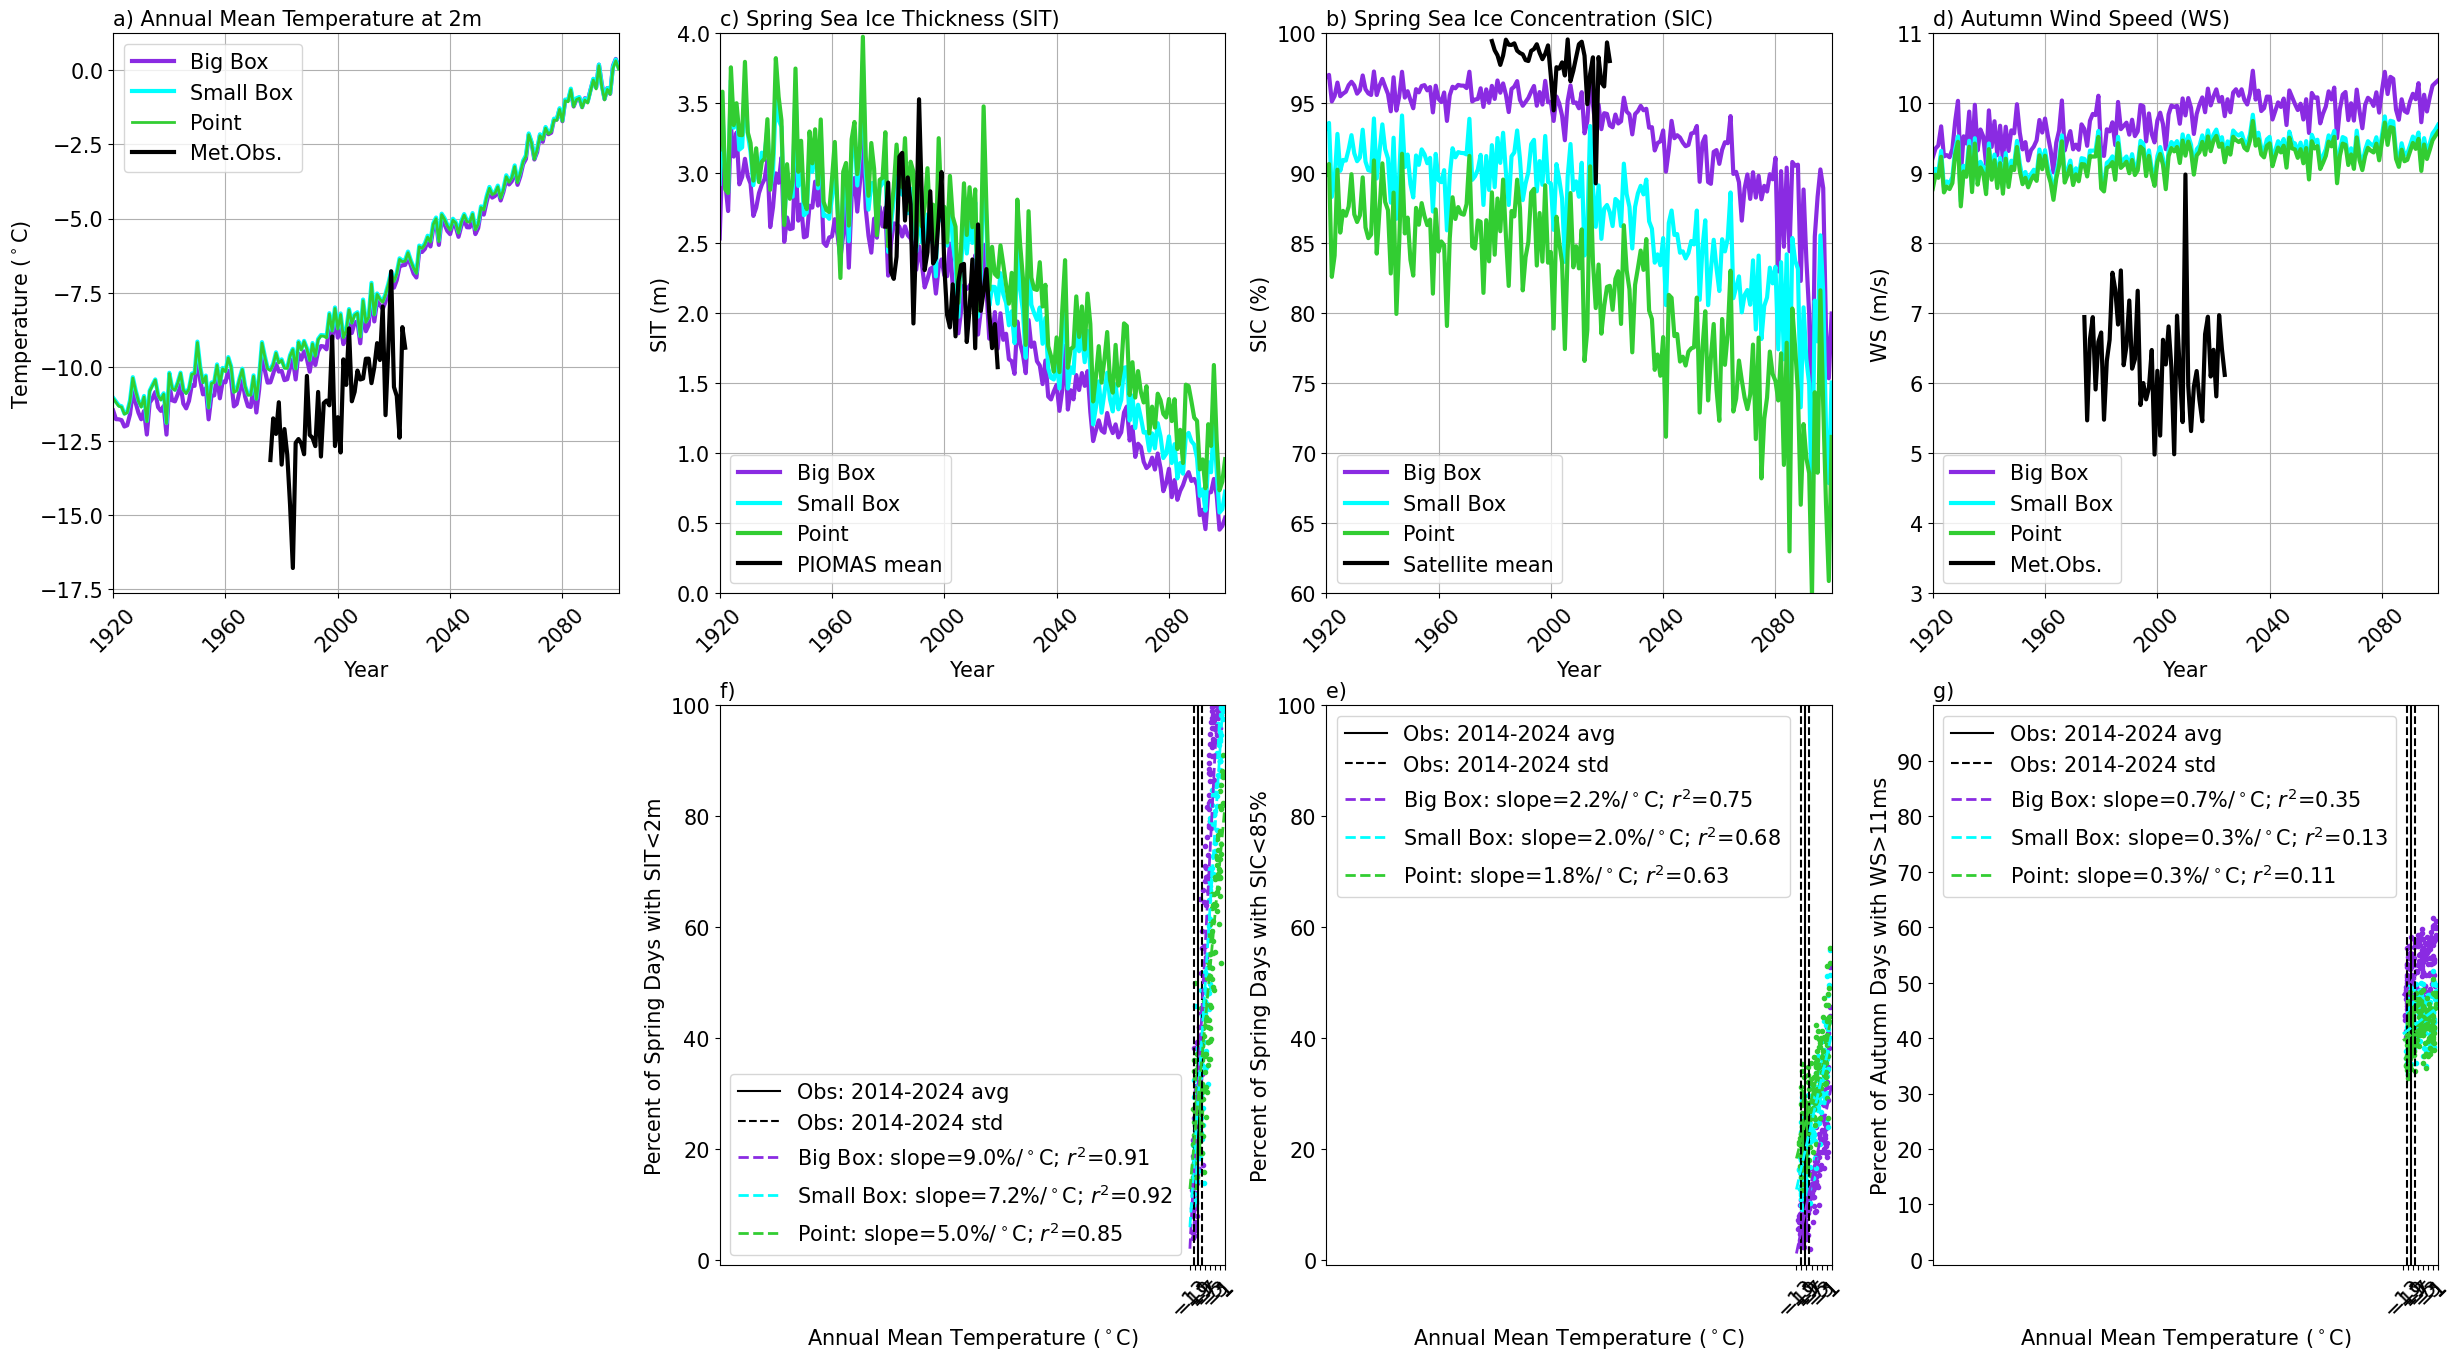

In [129]:
# create figure
#fig = plt.figure(figsize=(20,12))
fig = plt.figure(figsize=(30,16))
# now loop through months to create subpanels
fout = 'fig_7_legend'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### First grouping: Mean State Comparison
### Plot 1 - T2m ###
ax = fig.add_subplot(2,4,1)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_avg
data_std = mesaclip_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_small_box_avg
data_std = mesaclip_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_pt_avg
data_std = mesaclip_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=2)
# Obs from Barrow Observatory
ax.plot(years_obs_brw,data_obs_temp,color="black",label='Met.Obs.',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('a) Annual Mean Temperature at 2m',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
ax.set_xticks(xticks_ts)
plt.xlim([1920,2100])
plt.ylabel('Temperature ($^\\circ$C)',fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim([-1,100.0])
plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - SIT ###
ax = fig.add_subplot(2,4,2)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_sit_avg
data_std = mesaclip_sit_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_sit_small_box_avg
data_std = mesaclip_sit_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_sit_pt_avg
data_std = mesaclip_sit_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from PIOMAS
ax.plot(years_obs_sit,obs_sit_avg,color="black",label='PIOMAS mean',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('c) Spring Sea Ice Thickness (SIT)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIT (m)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,4])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 3 - SIC ###
ax = fig.add_subplot(2,4,3)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_sic_avg
data_std = mesaclip_sic_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_sic_small_box_avg
data_std = mesaclip_sic_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_sic_pt_avg
data_std = mesaclip_sic_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from SSMI
ax.plot(years_obs_sic,obs_sic_avg,color="black",label='Satellite mean',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('b) Spring Sea Ice Concentration (SIC)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('SIC (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([60,100])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 4 - WS ###
ax = fig.add_subplot(2,4,4)
## BigBox
c1 = 'blueviolet'
data_avg = mesaclip_ws_avg
data_std = mesaclip_ws_std
ax.plot(years_model,data_avg,color=c1,label='Big Box',linestyle='-',linewidth=3)
## Small Box
c1 = 'cyan'
data_avg = mesaclip_ws_small_box_avg
data_std = mesaclip_ws_small_box_std
ax.plot(years_model,data_avg,color=c1,label='Small Box',linestyle='-',linewidth=3)
## Single Pt
c1 = 'limegreen'
data_avg = mesaclip_ws_pt_avg
data_std = mesaclip_ws_pt_std
ax.plot(years_model,data_avg,color=c1,label='Point',linestyle='-',linewidth=3)
# Obs from Barrow Observatory
ax.plot(years_obs_brw,data_obs_ws,color="black",label='Met.Obs.',linestyle='-',linewidth=3)
# modify labels and legend
plt.title('d) Autumn Wind Speed (WS)',loc='left',fontsize=15)
plt.xlabel('Year',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([1920,2100])
ax.set_xticks(xticks_ts)
plt.ylabel('WS (m/s)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([3,11])
plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

############
### Second grouping - Temp vs. variable
### Plot 6 - T2m vs. SIT ###
ax = fig.add_subplot(2,4,6)
# set data
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="blueviolet",marker=".")
ax.scatter(mesaclip_small_box_avg,sit_thresh1_mesaclip_small_box,color="cyan",marker=".")
ax.scatter(mesaclip_pt_avg,sit_thresh1_mesaclip_pt,color="limegreen",marker=".")
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_sit_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_sit_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_bb)
ax.plot(x_reg,y_sit_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_sit_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_sb)
ax.plot(x_reg,y_sit_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_sit_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip_pt)
# modify labels and legend
plt.title('f) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-200,-6])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent of Spring Days with SIT<2m',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
plt.legend(loc='lower left', fontsize=15, ncol=1);

### Plot 7 - T2m vs. SIC ###
ax = fig.add_subplot(2,4,7)
# set data
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="blueviolet",marker=".")
ax.scatter(mesaclip_small_box_avg,sic_thresh1_mesaclip_small_box,color="cyan",marker=".")
ax.scatter(mesaclip_pt_avg,sic_thresh1_mesaclip_pt,color="limegreen",marker=".")
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_sic_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_sic_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_bb)
ax.plot(x_reg,y_sic_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_sic_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_sb)
ax.plot(x_reg,y_sic_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_sic_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip_pt)
# modify labels and legend
plt.title('e) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-200,-6])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 8 - T2m vs. WS ###
ax = fig.add_subplot(2,4,8)
# set data
ax.scatter(mesaclip_avg,ws_thresh1_mesaclip,color="blueviolet",marker=".")
ax.scatter(mesaclip_small_box_avg,ws_thresh1_mesaclip_small_box,color="cyan",marker=".")
ax.scatter(mesaclip_pt_avg,ws_thresh1_mesaclip_pt,color="limegreen",marker=".")
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# plot regressions
ax.plot(x_reg,y_ws_reg_mesaclip_bb,color='blueviolet',linestyle='--',linewidth=2,label='Big Box: slope='+rate_ws_mesaclip_bb+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_bb)
ax.plot(x_reg,y_ws_reg_mesaclip_sb,color='cyan',linestyle='--',linewidth=2,label='Small Box: slope='+rate_ws_mesaclip_sb+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_sb)
ax.plot(x_reg,y_ws_reg_mesaclip_pt,color='limegreen',linestyle='--',linewidth=2,label='Point: slope='+rate_ws_mesaclip_pt+'%/$^\\circ$C; $r^2$='+r2_ws_mesaclip_pt)
# modify labels and legend
plt.title('g) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-200,-6])
ax.set_xticks(xticks_sc)
plt.ylabel('Percent of Autumn Days with WS>11ms',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
ax.set_yticks(yticks_sc)
#plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);
############

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
#fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)